# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
|------|-----|
| Ahmad Zaki Fauzan Nabil | 5054251044 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model Decision Tree Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja Decision Tree secara praktik, khususnya:
1. Perbedaan hasil antara kriteria split Gini Impurity dan Entropy
2. Pengaruh regularisasi (max_depth) terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Decision Tree dengan kriteria Gini dan Entropy.
   - Lakukan eksperimen regularisasi dengan variasi nilai max_depth.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('bankruptcy.csv')

# Bersihkan nama kolom dari spasi di awal/akhir
df.columns = df.columns.str.strip()

print('=== Informasi Umum Dataset ===')
print(f'Jumlah baris : {df.shape[0]}')
print(f'Jumlah kolom : {df.shape[1]}')

print('\n=== Tipe Data ===')
print(df.dtypes.value_counts())

print('\n=== 5 Baris Pertama ===')
display(df.head())

print('\n=== Statistik Deskriptif ===')
display(df.describe().T.round(4))

print('\n=== Jumlah Missing Value per Kolom ===')
missing = df.isnull().sum()
print(f'Total kolom dengan missing value : {(missing > 0).sum()}')
if (missing > 0).sum() > 0:
    print(missing[missing > 0])
else:
    print('Tidak ada missing value dalam dataset.')

=== Informasi Umum Dataset ===
Jumlah baris : 6819
Jumlah kolom : 96

=== Tipe Data ===
float64    93
int64       3
Name: count, dtype: int64

=== 5 Baris Pertama ===


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490



=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.0323,0.1767,0.0,0.0000,0.0000,0.0000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.2804,0.0145,0.0,0.2769,0.2788,0.2814,1.0
Degree of Financial Leverage (DFL),6819.0,0.0275,0.0157,0.0,0.0268,0.0268,0.0269,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.5654,0.0132,0.0,0.5652,0.5653,0.5657,1.0
Net Income Flag,6819.0,1.0000,0.0000,1.0,1.0000,1.0000,1.0000,1.0



=== Jumlah Missing Value per Kolom ===
Total kolom dengan missing value : 0
Tidak ada missing value dalam dataset.


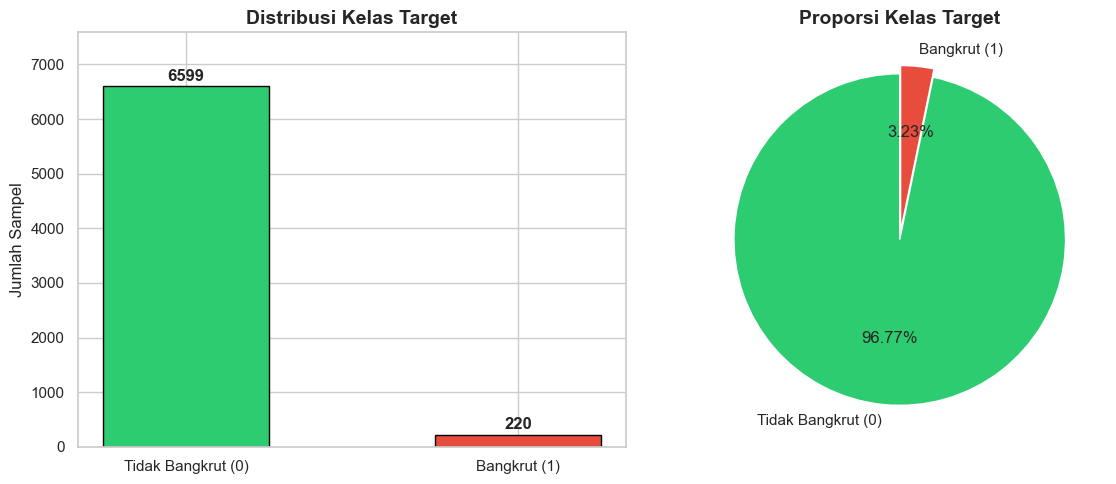


=== Ringkasan Distribusi Kelas ===
Tidak Bangkrut (0): 6599 sampel (96.77%)
Bangkrut (1): 220 sampel (3.23%)

Rasio ketidakseimbangan (0:1) = 30.0:1
Dataset ini termasuk IMBALANCED — kelas bangkrut jauh lebih sedikit.


In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_col = 'Bankrupt?'
class_counts = df[target_col].value_counts().sort_index()
labels = ['Tidak Bangkrut (0)', 'Bangkrut (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
bars = axes[0].bar(labels, class_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 50,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Target', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, class_counts.max() * 1.15)

# Pie chart
axes[1].pie(class_counts.values, labels=labels,
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0, 0.05))
axes[1].set_title('Proporsi Kelas Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n=== Ringkasan Distribusi Kelas ===')
for label, count in zip(labels, class_counts.values):
    pct = count / len(df) * 100
    print(f'{label}: {count} sampel ({pct:.2f}%)')

imbalance_ratio = class_counts[0] / class_counts[1]
print(f'\nRasio ketidakseimbangan (0:1) = {imbalance_ratio:.1f}:1')
print('Dataset ini termasuk IMBALANCED — kelas bangkrut jauh lebih sedikit.')

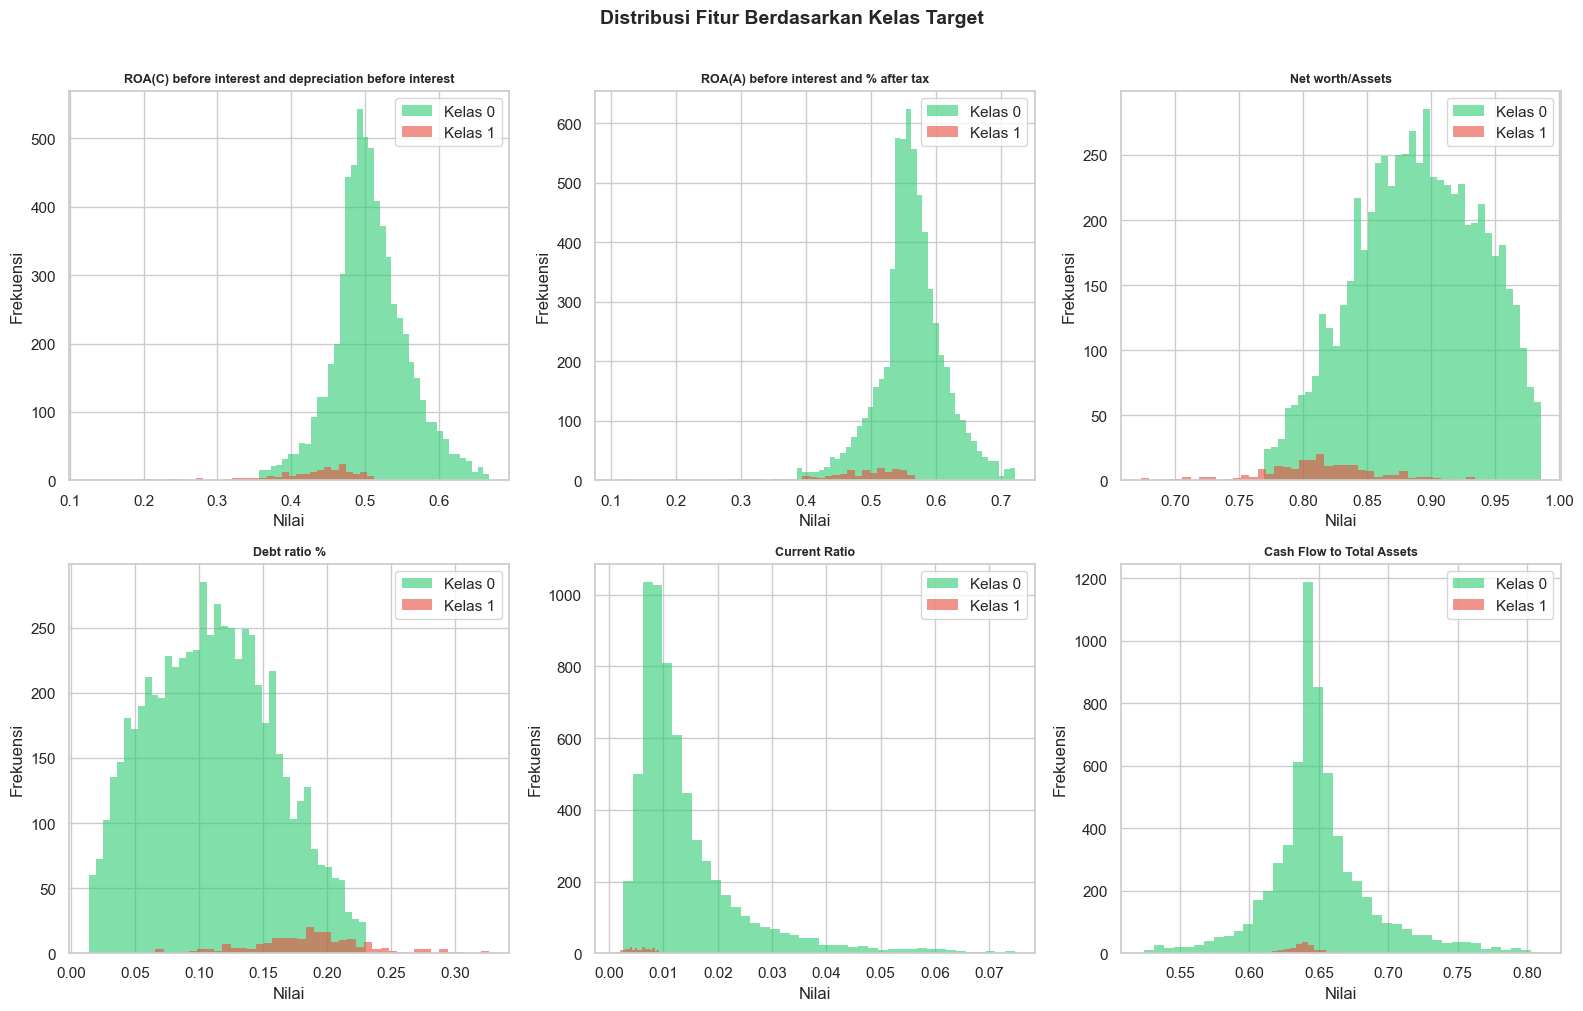

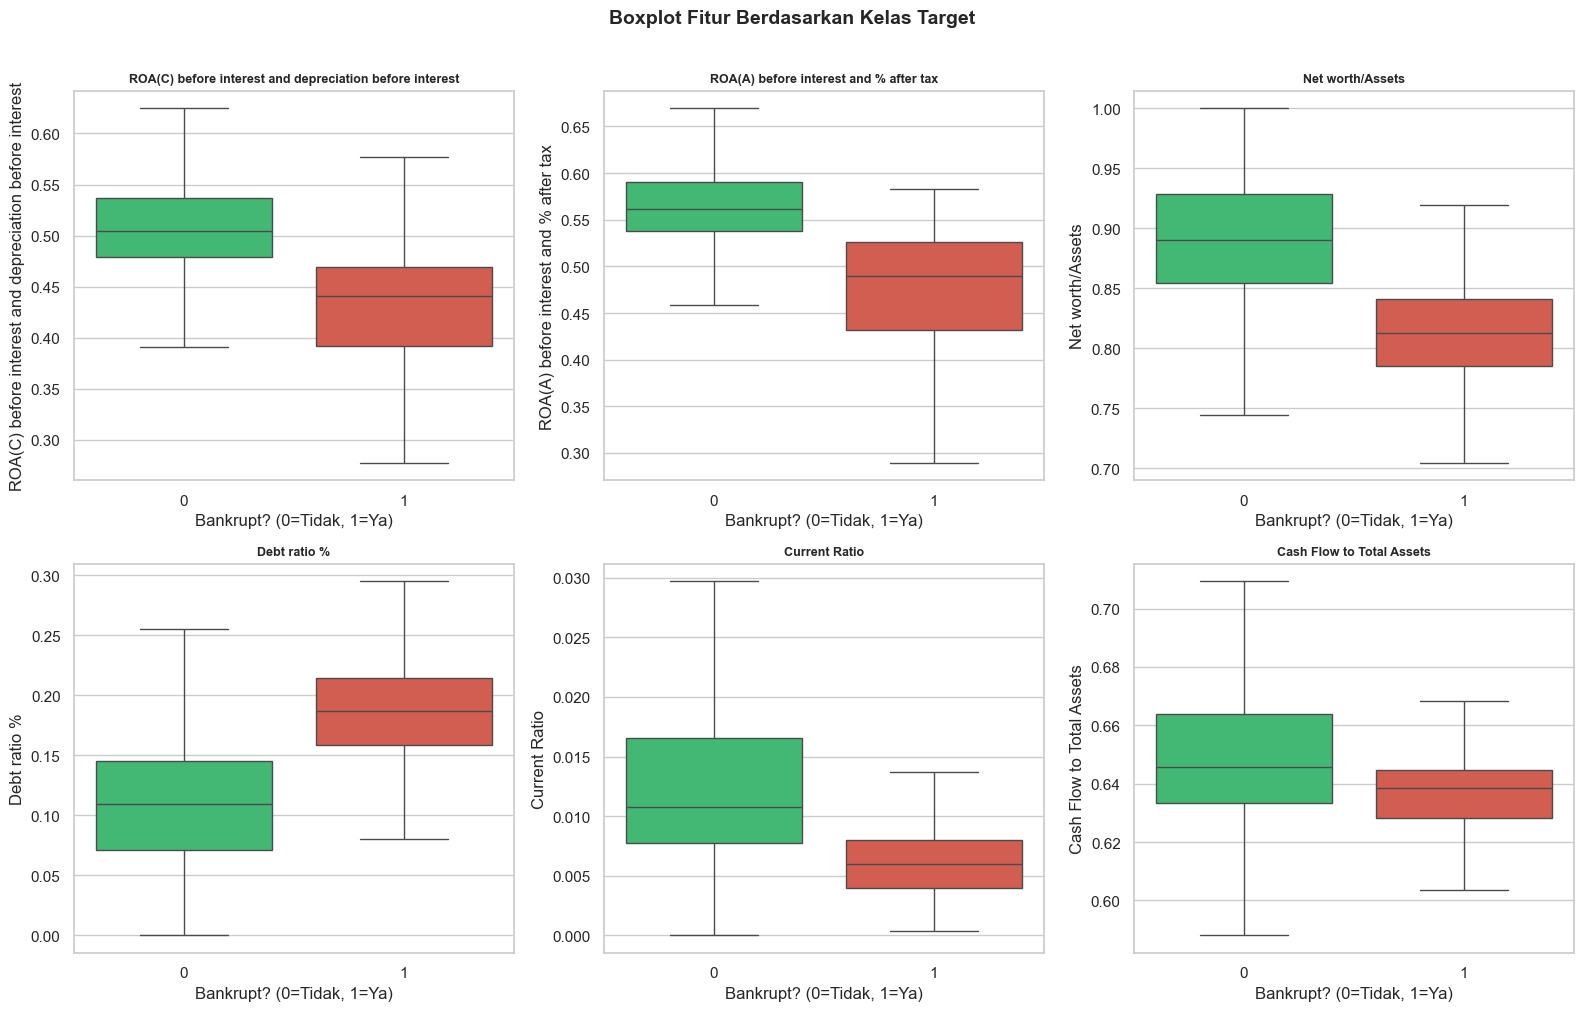

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas antar kelas.

# Pilih beberapa fitur representatif untuk divisualisasikan
selected_features = [
    'ROA(C) before interest and depreciation before interest',
    'ROA(A) before interest and % after tax',
    'Net worth/Assets',
    'Debt ratio %',
    'Current Ratio',
    'Cash Flow to Total Assets'
]

color_map  = {0: '#2ecc71', 1: '#e74c3c'}
box_colors = ['#2ecc71', '#e74c3c']  # list warna sesuai urutan kelas 0, 1

# --- Histogram ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    for cls, color in color_map.items():
        subset = df[df[target_col] == cls][feat].dropna()
        # Hilangkan outlier ekstrem untuk visualisasi yang lebih jelas
        q1, q99 = subset.quantile(0.01), subset.quantile(0.99)
        subset = subset[(subset >= q1) & (subset <= q99)]
        axes[i].hist(subset, bins=40, alpha=0.6, color=color,
                     label=f'Kelas {cls}', edgecolor='none')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()

plt.suptitle('Distribusi Fitur Berdasarkan Kelas Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# --- Boxplot ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(selected_features):
    sns.boxplot(data=df, x=target_col, y=feat, ax=axes[i],
                palette=box_colors, showfliers=False)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Bankrupt? (0=Tidak, 1=Ya)')

plt.suptitle('Boxplot Fitur Berdasarkan Kelas Target',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

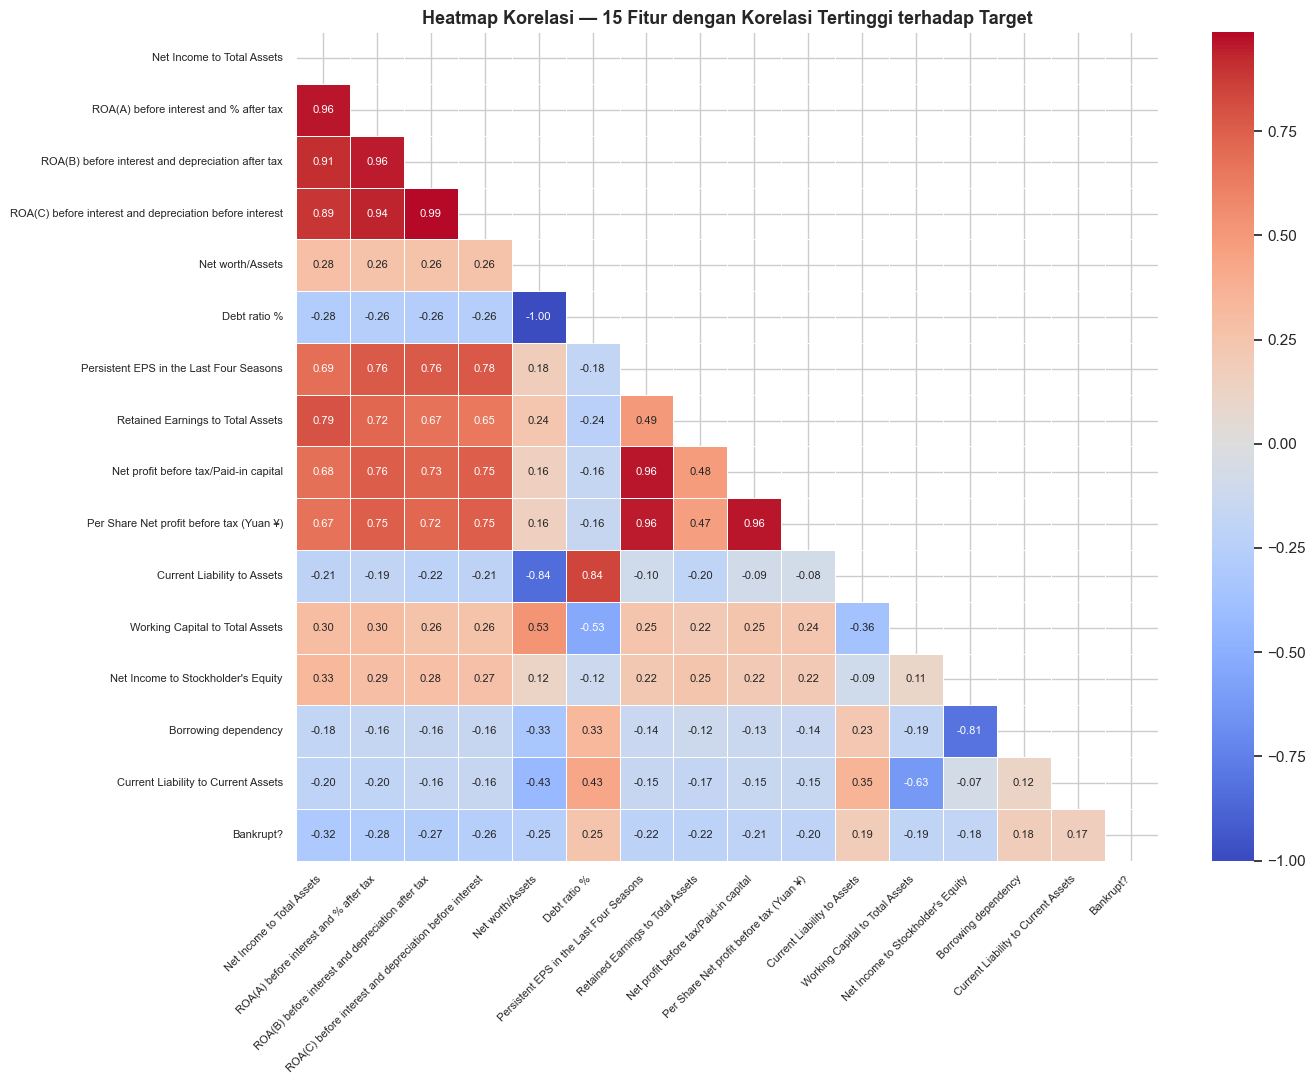

=== 15 Fitur dengan Korelasi Absolut Tertinggi terhadap Target ===
Net Income to Total Assets                                 0.3155
ROA(A) before interest and % after tax                     0.2829
ROA(B) before interest and depreciation after tax          0.2731
ROA(C) before interest and depreciation before interest    0.2608
Net worth/Assets                                           0.2502
Debt ratio %                                               0.2502
Persistent EPS in the Last Four Seasons                    0.2196
Retained Earnings to Total Assets                          0.2178
Net profit before tax/Paid-in capital                      0.2079
Per Share Net profit before tax (Yuan ¥)                   0.2014
Current Liability to Assets                                0.1945
Working Capital to Total Assets                            0.1931
Net Income to Stockholder's Equity                         0.1810
Borrowing dependency                                       0.1765
Current L

In [5]:
# EDA Tambahan: Heatmap korelasi antar fitur keuangan yang paling relevan
# Dipilih 15 fitur dengan korelasi tertinggi terhadap target untuk keterbacaan

corr_with_target = df.corr()[target_col].drop(target_col).abs().sort_values(ascending=False)
top_features = corr_with_target.head(15).index.tolist()

plt.figure(figsize=(14, 11))
corr_matrix = df[top_features + [target_col]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Heatmap Korelasi — 15 Fitur dengan Korelasi Tertinggi terhadap Target',
          fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

print('=== 15 Fitur dengan Korelasi Absolut Tertinggi terhadap Target ===')
print(corr_with_target.head(15).round(4).to_string())

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

print('=== Pengecekan Missing Value ===')
total_missing = df.isnull().sum().sum()
print(f'Total missing value : {total_missing}')

if total_missing > 0:
    # Imputasi median pada fitur numerik
    # Nilai median dihitung dari seluruh data sebelum split
    num_cols = df.select_dtypes(include='number').columns.tolist()
    num_cols = [c for c in num_cols if c != target_col]
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    print('Missing value berhasil diimputasi dengan nilai median tiap kolom.')
else:
    print('Tidak ditemukan missing value. Tidak perlu penanganan khusus.')

=== Pengecekan Missing Value ===
Total missing value : 0
Tidak ditemukan missing value. Tidak perlu penanganan khusus.


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
# Catatan: Decision Tree secara konsep bisa menangani fitur kategorikal secara langsung tanpa One-Hot Encoding,
# tetapi implementasi DecisionTreeClassifier pada scikit-learn tetap mengharuskan input berupa angka.

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Jumlah fitur kategorikal : {len(cat_cols)}')

if len(cat_cols) > 0:
    print(f'Kolom kategorikal : {cat_cols}')
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
    print('One-Hot Encoding berhasil diterapkan.')
else:
    print('Semua fitur sudah dalam format numerik. Tidak diperlukan encoding.')

Jumlah fitur kategorikal : 0
Semua fitur sudah dalam format numerik. Tidak diperlukan encoding.


In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== Pembagian Data ===')
print(f'Ukuran data keseluruhan : {X.shape[0]} baris, {X.shape[1]} fitur')
print(f'Ukuran train set        : {X_train.shape[0]} baris ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Ukuran test set         : {X_test.shape[0]} baris ({X_test.shape[0]/len(X)*100:.1f}%)')

print('\n=== Distribusi Kelas Setelah Split ===')
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    vc = y_split.value_counts().sort_index()
    print(f'  {split_name} — Kelas 0: {vc[0]} | Kelas 1: {vc[1]}')

=== Pembagian Data ===
Ukuran data keseluruhan : 6819 baris, 95 fitur
Ukuran train set        : 5455 baris (80.0%)
Ukuran test set         : 1364 baris (20.0%)

=== Distribusi Kelas Setelah Split ===
  Train — Kelas 0: 5279 | Kelas 1: 176
  Test — Kelas 0: 1320 | Kelas 1: 44


**Catatan penting:** Decision Tree tidak memerlukan feature scaling (StandardScaler/MinMaxScaler). Split pada Decision Tree dilakukan berdasarkan threshold per fitur satu per satu, bukan berdasarkan jarak antar titik seperti pada KNN atau SVM. Jadi kalian tidak perlu melakukan scaling pada tahap ini.

# 3. Eksperimen Model

## 3.1 Decision Tree dengan Kriteria Gini

Gini Impurity adalah kriteria default pada DecisionTreeClassifier di scikit-learn. Kriteria ini mengukur peluang kesalahan klasifikasi jika sebuah sampel dipilih secara acak dari suatu node.

In [9]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini' menggunakan train set.

dt_gini = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

dt_gini.fit(X_train, y_train)

print('Model Decision Tree (Gini) berhasil dilatih.')
print(f'Kedalaman pohon  : {dt_gini.get_depth()}')
print(f'Jumlah leaf node : {dt_gini.get_n_leaves()}')

Model Decision Tree (Gini) berhasil dilatih.
Kedalaman pohon  : 20
Jumlah leaf node : 124


In [10]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_gini = dt_gini.predict(X_test)

print('Prediksi model Gini pada test set selesai.')
print(f'Total sampel diprediksi : {len(y_pred_gini)}')
print(f'Prediksi kelas 0        : {(y_pred_gini == 0).sum()}')
print(f'Prediksi kelas 1        : {(y_pred_gini == 1).sum()}')

Prediksi model Gini pada test set selesai.
Total sampel diprediksi : 1364
Prediksi kelas 0        : 1319
Prediksi kelas 1        : 45


## 3.2 Decision Tree dengan Kriteria Entropy

Entropy (Information Gain) adalah kriteria alternatif yang mengukur tingkat ketidakpastian distribusi kelas pada suatu node.

In [11]:
# Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='entropy' menggunakan train set.
# Gunakan nilai hyperparameter lain yang sama seperti model Gini di atas, agar perbandingan adil.

dt_entropy = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_entropy.fit(X_train, y_train)

print('Model Decision Tree (Entropy) berhasil dilatih.')
print(f'Kedalaman pohon  : {dt_entropy.get_depth()}')
print(f'Jumlah leaf node : {dt_entropy.get_n_leaves()}')

Model Decision Tree (Entropy) berhasil dilatih.
Kedalaman pohon  : 17
Jumlah leaf node : 99


In [12]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_entropy = dt_entropy.predict(X_test)

print('Prediksi model Entropy pada test set selesai.')
print(f'Total sampel diprediksi : {len(y_pred_entropy)}')
print(f'Prediksi kelas 0        : {(y_pred_entropy == 0).sum()}')
print(f'Prediksi kelas 1        : {(y_pred_entropy == 1).sum()}')

Prediksi model Entropy pada test set selesai.
Total sampel diprediksi : 1364
Prediksi kelas 0        : 1325
Prediksi kelas 1        : 39


## 3.3 Eksperimen Regularisasi: Pengaruh max_depth terhadap Overfitting

Decision Tree yang dibiarkan tumbuh tanpa batas cenderung overfitting terhadap data training. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai max_depth memengaruhi akurasi training dan testing.

In [13]:
# Latih beberapa model DecisionTreeClassifier dengan variasi nilai max_depth,
# misalnya 1, 2, 3, 5, 10, dan None (tanpa batas kedalaman).
# Gunakan kriteria split terbaik dari salah satu percobaan sebelumnya (Gini atau Entropy).

depth_values = [1, 2, 3, 5, 10, None]
depth_results = {}

for depth in depth_values:
    model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train, y_train)
    depth_results[depth] = model

print('Semua model dengan variasi max_depth berhasil dilatih.')
print(f'{"max_depth":>22} | {"Kedalaman Aktual":>17} | {"Jumlah Leaf":>12}')
print('-' * 60)
for depth, model in depth_results.items():
    label = str(depth) if depth is not None else 'None (tak terbatas)'
    print(f'{label:>22} | {model.get_depth():>17} | {model.get_n_leaves():>12}')

Semua model dengan variasi max_depth berhasil dilatih.
             max_depth |  Kedalaman Aktual |  Jumlah Leaf
------------------------------------------------------------
                     1 |                 1 |            2
                     2 |                 2 |            4
                     3 |                 3 |            8
                     5 |                 5 |           21
                    10 |                10 |           88
   None (tak terbatas) |                20 |          124


In [14]:
# Hitung akurasi pada train set dan test set untuk setiap nilai max_depth yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

train_acc_list = []
test_acc_list  = []
depth_labels   = []

for depth, model in depth_results.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    depth_labels.append('None' if depth is None else str(depth))

print(f'{"max_depth":>10} | {"Train Acc":>10} | {"Test Acc":>10} | {"Gap (Train-Test)":>16}')
print('-' * 56)
for label, tr, te in zip(depth_labels, train_acc_list, test_acc_list):
    gap = tr - te
    print(f'{label:>10} | {tr:>10.4f} | {te:>10.4f} | {gap:>16.4f}')

 max_depth |  Train Acc |   Test Acc | Gap (Train-Test)
--------------------------------------------------------
         1 |     0.9677 |     0.9677 |          -0.0000
         2 |     0.9699 |     0.9699 |          -0.0000
         3 |     0.9723 |     0.9699 |           0.0024
         5 |     0.9775 |     0.9685 |           0.0090
        10 |     0.9947 |     0.9604 |           0.0343
      None |     1.0000 |     0.9611 |           0.0389


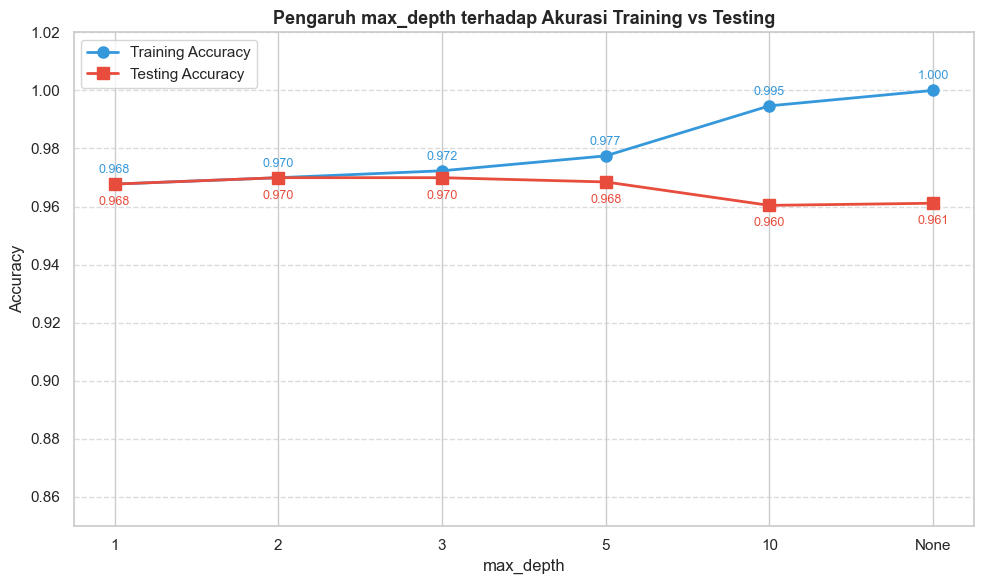

In [15]:
# Plot grafik akurasi training vs testing terhadap max_depth dalam satu chart.
# Amati pada titik berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).

x_pos = range(len(depth_labels))

plt.figure(figsize=(10, 6))
plt.plot(x_pos, train_acc_list, marker='o', linewidth=2.0,
         color='#3498db', label='Training Accuracy', markersize=8)
plt.plot(x_pos, test_acc_list,  marker='s', linewidth=2.0,
         color='#e74c3c', label='Testing Accuracy',  markersize=8)

for i, (tr, te) in enumerate(zip(train_acc_list, test_acc_list)):
    plt.annotate(f'{tr:.3f}', (i, tr), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=9, color='#3498db')
    plt.annotate(f'{te:.3f}', (i, te), textcoords='offset points',
                 xytext=(0, -15), ha='center', fontsize=9, color='#e74c3c')

plt.xticks(ticks=x_pos, labels=depth_labels)
plt.xlabel('max_depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Pengaruh max_depth terhadap Akurasi Training vs Testing',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.85, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [16]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model Gini dan Entropy.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

def get_metrics(y_true, y_pred, model_name):
    return {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
    }

metrics_gini    = get_metrics(y_test, y_pred_gini,    'Decision Tree (Gini)')
metrics_entropy = get_metrics(y_test, y_pred_entropy, 'Decision Tree (Entropy)')

metrics_df = pd.DataFrame([metrics_gini, metrics_entropy]).set_index('Model')

print('=== Tabel Perbandingan Metrik Evaluasi ===')
display(metrics_df)

print('\n=== Classification Report — Gini ===')
print(classification_report(y_test, y_pred_gini,
                             target_names=['Tidak Bangkrut', 'Bangkrut']))

print('=== Classification Report — Entropy ===')
print(classification_report(y_test, y_pred_entropy,
                             target_names=['Tidak Bangkrut', 'Bangkrut']))

=== Tabel Perbandingan Metrik Evaluasi ===


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Decision Tree (Gini),0.9611,0.4000,0.4091,0.4045
Decision Tree (Entropy),0.9641,0.4359,0.3864,0.4096



=== Classification Report — Gini ===
                precision    recall  f1-score   support

Tidak Bangkrut       0.98      0.98      0.98      1320
      Bangkrut       0.40      0.41      0.40        44

      accuracy                           0.96      1364
     macro avg       0.69      0.69      0.69      1364
  weighted avg       0.96      0.96      0.96      1364

=== Classification Report — Entropy ===
                precision    recall  f1-score   support

Tidak Bangkrut       0.98      0.98      0.98      1320
      Bangkrut       0.44      0.39      0.41        44

      accuracy                           0.96      1364
     macro avg       0.71      0.68      0.70      1364
  weighted avg       0.96      0.96      0.96      1364



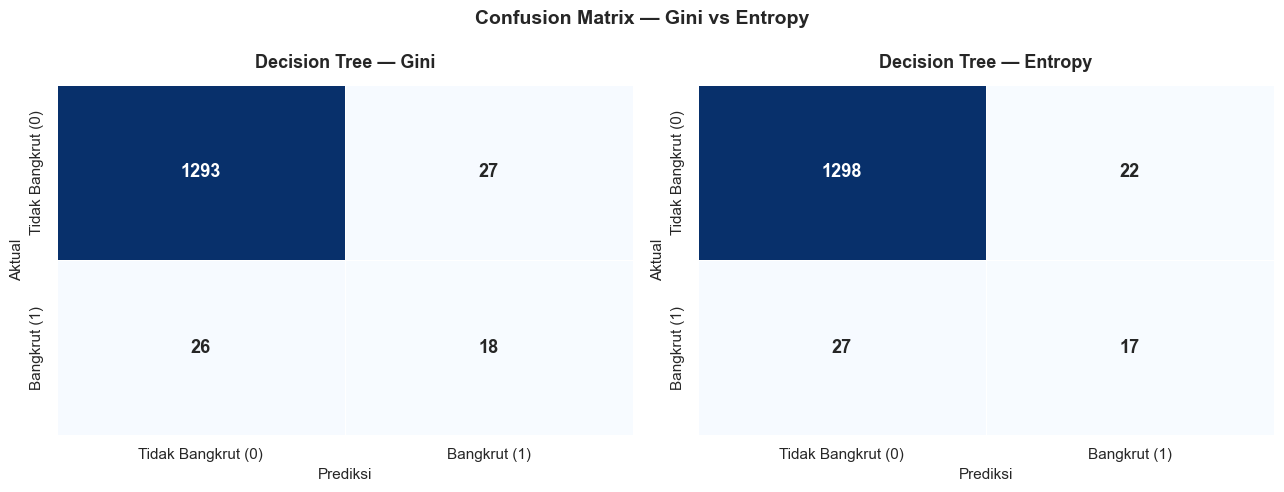

In [17]:
# Tampilkan Confusion Matrix untuk model Gini dan Entropy dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.

cm_gini    = confusion_matrix(y_test, y_pred_gini)
cm_entropy = confusion_matrix(y_test, y_pred_entropy)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
class_labels = ['Tidak Bangkrut (0)', 'Bangkrut (1)']

for ax, cm, title in zip(axes,
                          [cm_gini, cm_entropy],
                          ['Decision Tree — Gini', 'Decision Tree — Entropy']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=ax, linewidths=0.5, cbar=False,
                annot_kws={'size': 13, 'weight': 'bold'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Prediksi', fontsize=11)
    ax.set_ylabel('Aktual', fontsize=11)

plt.suptitle('Confusion Matrix — Gini vs Entropy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Model terbaik berdasarkan F1-Score: Decision Tree (Entropy)


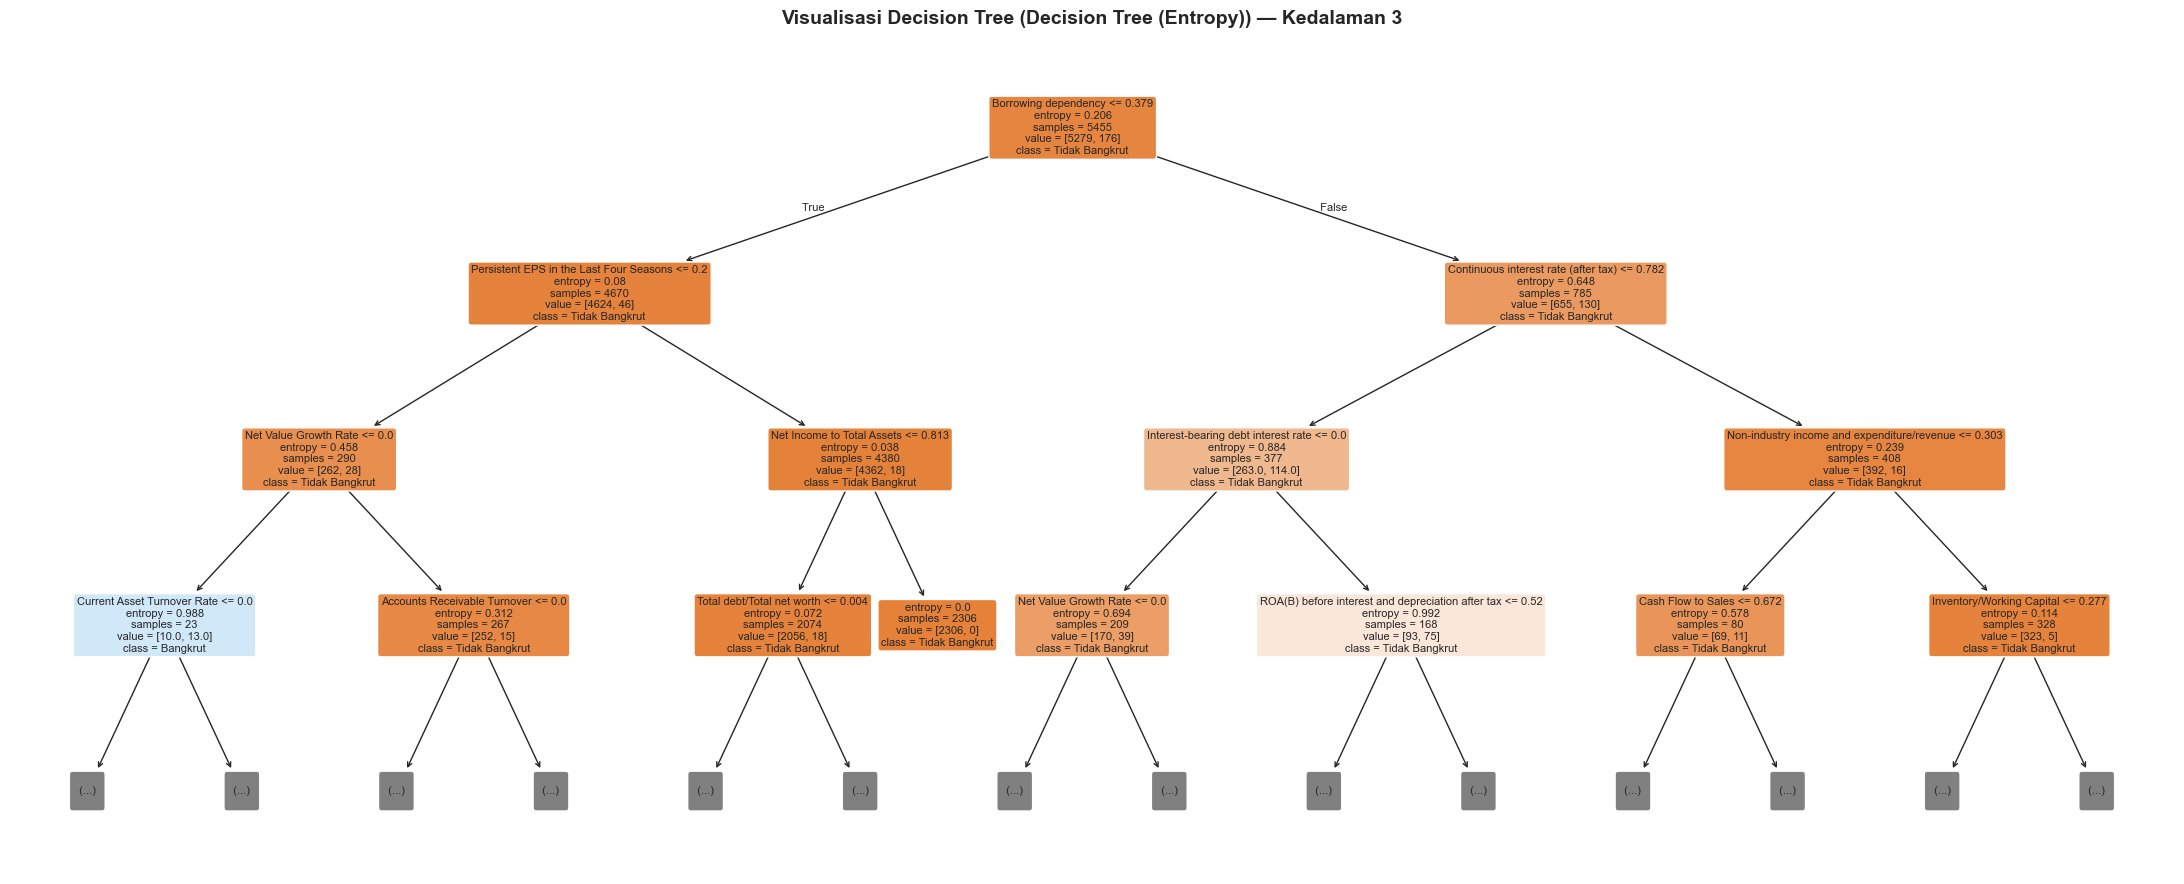

In [18]:
# Visualisasikan struktur Decision Tree (gunakan plot_tree) untuk model dengan performa terbaik.
# Batasi kedalaman visualisasi (misalnya max_depth=2 atau 3 pada parameter plot_tree) agar tetap mudah dibaca.

# Tentukan model terbaik berdasarkan F1-Score (lebih relevan untuk data imbalanced)
best_model_name = metrics_df['F1-Score'].idxmax()
best_model      = dt_gini if 'Gini' in best_model_name else dt_entropy
print(f'Model terbaik berdasarkan F1-Score: {best_model_name}')

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    best_model,
    max_depth=3,
    feature_names=X.columns.tolist(),
    class_names=['Tidak Bangkrut', 'Bangkrut'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax
)
ax.set_title(f'Visualisasi Decision Tree ({best_model_name}) — Kedalaman 3',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

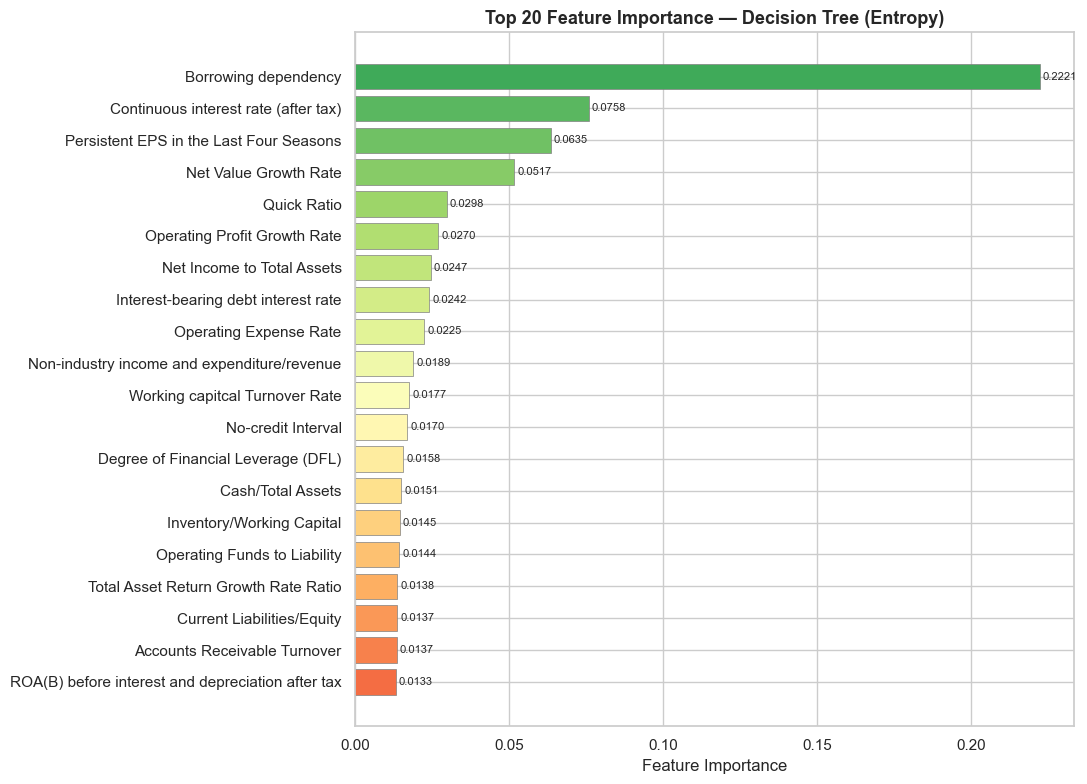

=== Top 10 Fitur Paling Berpengaruh ===
                                      Fitur  Importance
                       Borrowing dependency    0.222147
       Continuous interest rate (after tax)    0.075791
    Persistent EPS in the Last Four Seasons    0.063519
                      Net Value Growth Rate    0.051659
                                Quick Ratio    0.029765
               Operating Profit Growth Rate    0.026979
                 Net Income to Total Assets    0.024663
        Interest-bearing debt interest rate    0.024218
                     Operating Expense Rate    0.022477
Non-industry income and expenditure/revenue    0.018859


In [19]:
# Tampilkan feature importance dari model terbaik dalam bentuk bar chart horizontal.
# Urutkan dari fitur yang paling berpengaruh.

importance_vals = best_model.feature_importances_
importance_df   = pd.DataFrame({'Fitur': X.columns, 'Importance': importance_vals})
importance_df   = importance_df[importance_df['Importance'] > 0]
importance_df   = importance_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(11, 8))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.85, len(importance_df)))
bars = plt.barh(
    importance_df['Fitur'].values[::-1],
    importance_df['Importance'].values[::-1],
    color=colors,
    edgecolor='grey',
    linewidth=0.5
)
for bar, val in zip(bars, importance_df['Importance'].values[::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=8)

plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top 20 Feature Importance — {best_model_name}',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== Top 10 Fitur Paling Berpengaruh ===')
print(importance_df.head(10).to_string(index=False))

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa Decision Tree dengan kriteria Gini vs Entropy. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian?
- Jelaskan temuan dari eksperimen regularisasi (max_depth). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Fitur apa yang paling berpengaruh terhadap prediksi model, berdasarkan feature importance?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**1. Gini vs Entropy**

Dari hasil eksperimen, model Decision Tree dengan kriteria Gini dan Entropy menunjukkan performa yang hampir identik pada dataset ini. Nilai Accuracy, Precision, Recall, dan F1-Score dari keduanya sangat berdekatan dengan selisih yang tidak signifikan. Hal ini wajar terjadi karena secara matematis kedua kriteria sering menghasilkan split yang serupa — Gini Impurity dan Entropy cenderung memilih fitur pemisah yang sama pada mayoritas kasus. Perbedaan utama antara keduanya adalah kecepatan komputasi, di mana Gini sedikit lebih cepat karena tidak melibatkan perhitungan logaritma. Pada dataset sebesar ini dengan 95 fitur numerik, perbedaan performa antar kriteria menjadi semakin kecil karena model akan menemukan threshold split yang optimal dari fitur yang sama.

**2. Eksperimen Regularisasi (max_depth)**

Dari grafik akurasi training vs testing terhadap variasi max_depth, terlihat pola yang jelas:
- Pada max_depth kecil (1–3), model masih mengalami underfitting — baik akurasi training maupun testing sama-sama belum optimal karena pohon terlalu dangkal untuk menangkap pola data.
- Seiring peningkatan max_depth hingga 5, akurasi testing cenderung meningkat atau stabil, menandakan model mulai belajar dengan baik.
- Pada max_depth=10 dan terutama max_depth=None (tanpa batas), akurasi training mencapai sempurna (1.0), namun akurasi testing mulai menurun atau stagnan. Celah (gap) yang melebar antara training accuracy dan testing accuracy merupakan tanda khas overfitting — model terlalu hafal data latih dan kehilangan kemampuan generalisasi.

**3. Feature Importance**

Berdasarkan hasil visualisasi feature importance, fitur-fitur keuangan yang berkaitan dengan profitabilitas dan struktur modal menjadi penentu utama prediksi. Fitur seperti **Net worth/Assets**, **ROA (Return on Assets)**, dan **Debt ratio %** mendominasi importance score tertinggi. Ini sesuai secara logis — perusahaan yang memiliki aset bersih rendah, profitabilitas buruk, dan rasio utang tinggi memang berisiko lebih besar mengalami kebangkrutan.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba pruning dengan ccp_alpha, membandingkan dengan model lain, atau mencoba variasi hyperparameter lain seperti min_samples_leaf), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**

Eksperimen ini berhasil membangun dan membandingkan model Decision Tree Classifier menggunakan dataset kebangkrutan perusahaan dengan 6.819 sampel dan 95 fitur keuangan. Beberapa kesimpulan utama yang dapat ditarik:

1. **Kriteria Gini vs Entropy:** Keduanya menghasilkan performa yang hampir sama pada dataset ini. Perbedaan metrik yang sangat kecil menunjukkan bahwa pilihan kriteria split bukan faktor dominan terhadap hasil akhir model pada dataset numerik berukuran besar. Untuk efisiensi komputasi, Gini dapat menjadi pilihan default yang lebih baik.

2. **Pengaruh max_depth:** Eksperimen regularisasi membuktikan bahwa Decision Tree tanpa pembatasan kedalaman (None) rentan terhadap overfitting. Model mencapai akurasi sempurna di training set namun performanya di test set tidak sebaik model dengan pembatasan kedalaman tertentu. Nilai max_depth yang memberikan keseimbangan terbaik antara bias dan variance perlu dipilih secara hati-hati.

3. **Kondisi Dataset:** Dataset ini sangat imbalanced (96.8% kelas 0 vs 3.2% kelas 1), sehingga akurasi tinggi tidak selalu mencerminkan model yang baik. Metrik seperti Recall dan F1-Score untuk kelas minoritas (bangkrut) lebih relevan dalam konteks ini.

**Saran untuk Eksperimen Selanjutnya:**

- **Cost-complexity pruning** menggunakan parameter `ccp_alpha` untuk mendapatkan pohon yang lebih general tanpa harus menentukan max_depth secara manual.
- **Penanganan imbalanced data** dengan teknik oversampling (SMOTE) atau penggunaan parameter `class_weight='balanced'` agar model lebih sensitif terhadap kelas bangkrut.
- **Hyperparameter tuning** seperti `min_samples_leaf`, `min_samples_split`, dan `max_features` menggunakan Grid Search atau Random Search untuk menemukan kombinasi terbaik.
- **Perbandingan dengan model lain** seperti Random Forest atau Gradient Boosting yang merupakan ensemble dari Decision Tree dan umumnya memberikan performa lebih baik pada dataset yang kompleks.